
## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score




## Chargement et exploration initiale (EDA)

In [2]:
data = pd.read_excel('Sales_Data.xlsx')
data.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [3]:
print(f'Shape : {data.shape}')
print()
data.dtypes

Shape : (541909, 8)



InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
print('Valeurs manquantes par colonne :')
print(data.isnull().sum())
print()
print(f'Doublons : {data.duplicated().sum()}')

Valeurs manquantes par colonne :
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Doublons : 5268


In [6]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [7]:
# Points d'attention détectés (classiques sur ce type de dataset e-commerce) :
print('Quantity <= 0 (retours) :', (data['Quantity'] <= 0).sum())
print('UnitPrice <= 0 (lignes gratuites/erreurs) :', (data['UnitPrice'] <= 0).sum())
print("InvoiceNo commençant par 'C' (annulations) :", data['InvoiceNo'].astype(str).str.startswith('C').sum())
print('CustomerID manquant :', data['CustomerID'].isnull().sum())

Quantity <= 0 (retours) : 10624
UnitPrice <= 0 (lignes gratuites/erreurs) : 2517
InvoiceNo commençant par 'C' (annulations) : 9288
CustomerID manquant : 135080



### PARTIE 2 — PRÉTRAITEMENT AVANCÉ 

In [8]:
# 2.1 — SUPPRESSION DES VALEURS NULLES (CustomerID, Description)
avant = data.shape[0]

data = data.dropna(subset=['CustomerID'])
print(f'Lignes avant : {avant} | après suppression CustomerID nul : {data.shape[0]}')
print(f'Lignes supprimées : {avant - data.shape[0]}')

print()
print('Valeurs manquantes restantes :')
print(data.isnull().sum())

Lignes avant : 541909 | après suppression CustomerID nul : 406829
Lignes supprimées : 135080

Valeurs manquantes restantes :
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [9]:
# 2.2 — SUPPRESSION DES DOUBLONS

avant = data.shape[0]
data = data.drop_duplicates()
print(f'Lignes avant : {avant} | après suppression doublons : {data.shape[0]}')
print(f'Doublons supprimés : {avant - data.shape[0]}')

Lignes avant : 406829 | après suppression doublons : 401604
Doublons supprimés : 5225


In [10]:

# 2.3 — SUPPRESSION DES ANNULATIONS / RETOURS

avant = data.shape[0]

data = data[~data['InvoiceNo'].astype(str).str.startswith('C')]

# Lignes incohérentes : quantité ou prix unitaire négatif/nul
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]

print(f'Lignes avant : {avant} | après suppression annulations/incohérences : {data.shape[0]}')
print(f'Lignes supprimées : {avant - data.shape[0]}')

Lignes avant : 401604 | après suppression annulations/incohérences : 392692
Lignes supprimées : 8912


In [11]:
# 2.4 — CONVERSION DE InvoiceDate EN FORMAT DATE

data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

print(f'Type de InvoiceDate après conversion : {data["InvoiceDate"].dtype}')
print(f'Période couverte : du {data["InvoiceDate"].min()} au {data["InvoiceDate"].max()}')

Type de InvoiceDate après conversion : datetime64[ns]
Période couverte : du 2010-12-01 08:26:00 au 2011-12-09 12:50:00


In [12]:
# RÉCAPITULATIF DU NETTOYAGE

print(f'Shape finale après nettoyage : {data.shape}')
print(f'Nombre de clients uniques   : {data["CustomerID"].nunique()}')
print(f'Nombre de factures uniques  : {data["InvoiceNo"].nunique()}')
data.head()

Shape finale après nettoyage : (392692, 8)
Nombre de clients uniques   : 4338
Nombre de factures uniques  : 18532


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
### 3 — FEATURE ENGINEERING (Construction du RFM)

In [13]:
# 3.1 — Montant total par ligne de commande
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']
data[['Quantity', 'UnitPrice', 'TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [14]:
# 3.2 — Date de référence (snapshot)

snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Date de référence (snapshot) : {snapshot_date}')

Date de référence (snapshot) : 2011-12-10 12:50:00


In [15]:
# 3.3 — CONSTRUCTION DU TABLEAU RFM (1 ligne par client)

rfm = data.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(f'Nombre de clients dans le tableau RFM : {rfm.shape[0]}')
rfm.head(10)

Nombre de clients dans le tableau RFM : 4338


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


In [16]:
# Statistiques descriptives du RFM
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


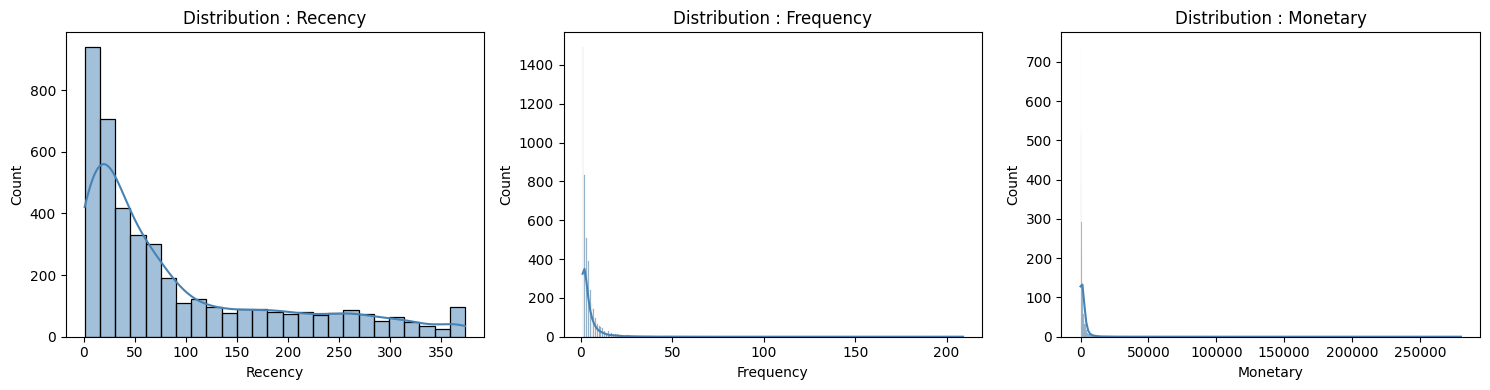

In [17]:
# Distribution visuelle des 3 variables RFM (avant normalisation)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution : {col}')
plt.tight_layout()
plt.show()


### PARTIE 4 — CLUSTERING (K-Means)

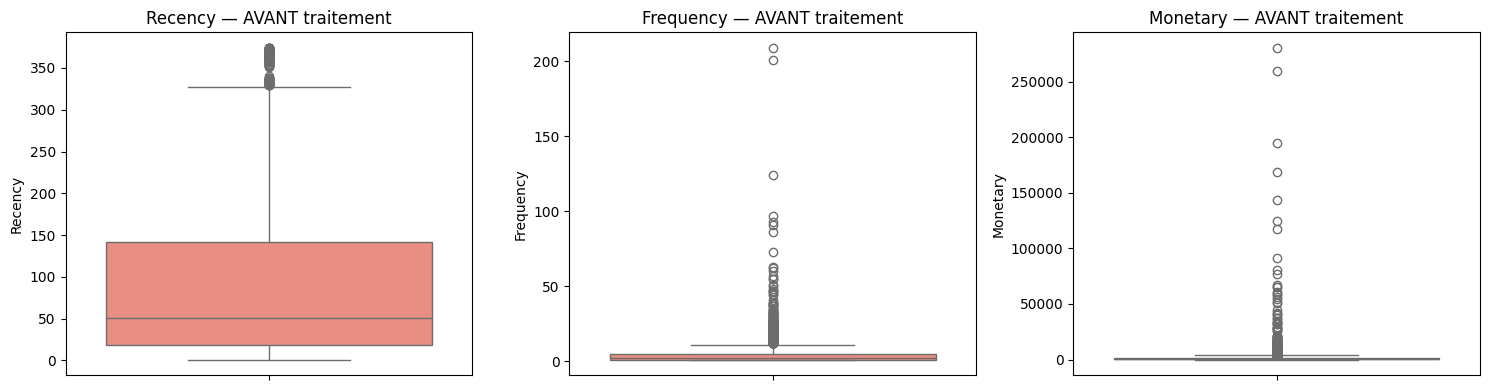

In [18]:
def replace_outliers(df, cols):
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        df[col] = np.where(df[col] < lower, lower, df[col])
        df[col] = np.where(df[col] > upper, upper, df[col])

# Boxplot AVANT traitement
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(y=rfm[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'{col} — AVANT traitement')
plt.tight_layout()
plt.show()

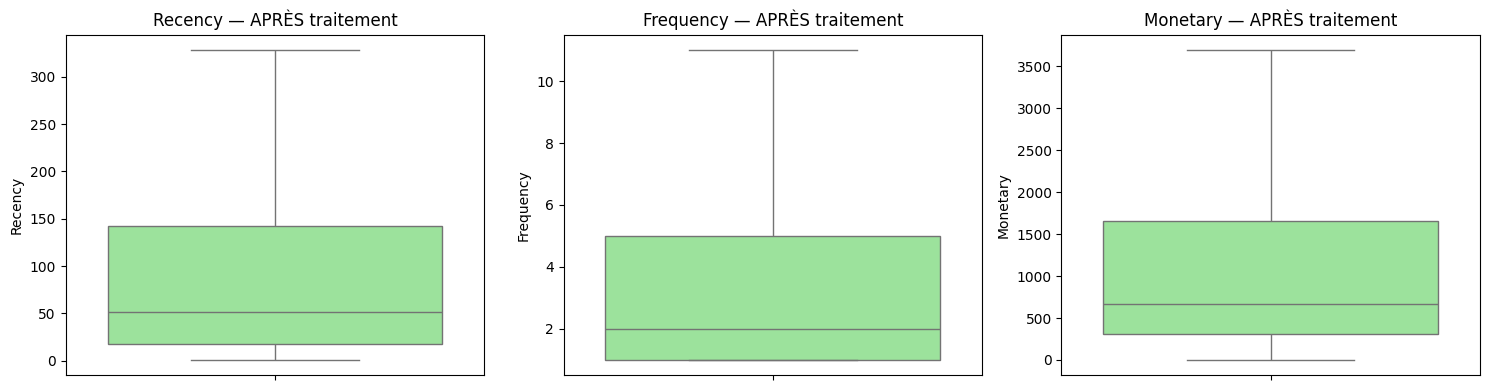

,Recency,Frequency,Monetary
count,4338.000000,4338.00000,4338.000000
mean,91.447441,3.48663,1159.010762
std,97.199547,3.04011,1146.777473
min,1.000000,1.00000,3.750000
25%,18.000000,1.00000,306.482500
50%,51.000000,2.00000,668.570000
75%,142.000000,5.00000,1660.597500
max,328.000000,11.00000,3691.770000


In [19]:
replace_outliers(rfm, ['Recency', 'Frequency', 'Monetary'])

# Boxplot APRÈS traitement
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(y=rfm[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'{col} — APRÈS traitement')
plt.tight_layout()
plt.show()

rfm[['Recency', 'Frequency', 'Monetary']].describe()

### 4.2 — Normalisation des variables RFM

In [20]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print('Moyenne après scaling (≈0) :', rfm_scaled.mean(axis=0).round(4))
print('Écart-type après scaling (≈1) :', rfm_scaled.std(axis=0).round(4))

Moyenne après scaling (≈0) : [ 0.  0. -0.]
Écart-type après scaling (≈1) : [1. 1. 1.]


### 4.3 — Détermination du nombre optimal de clusters

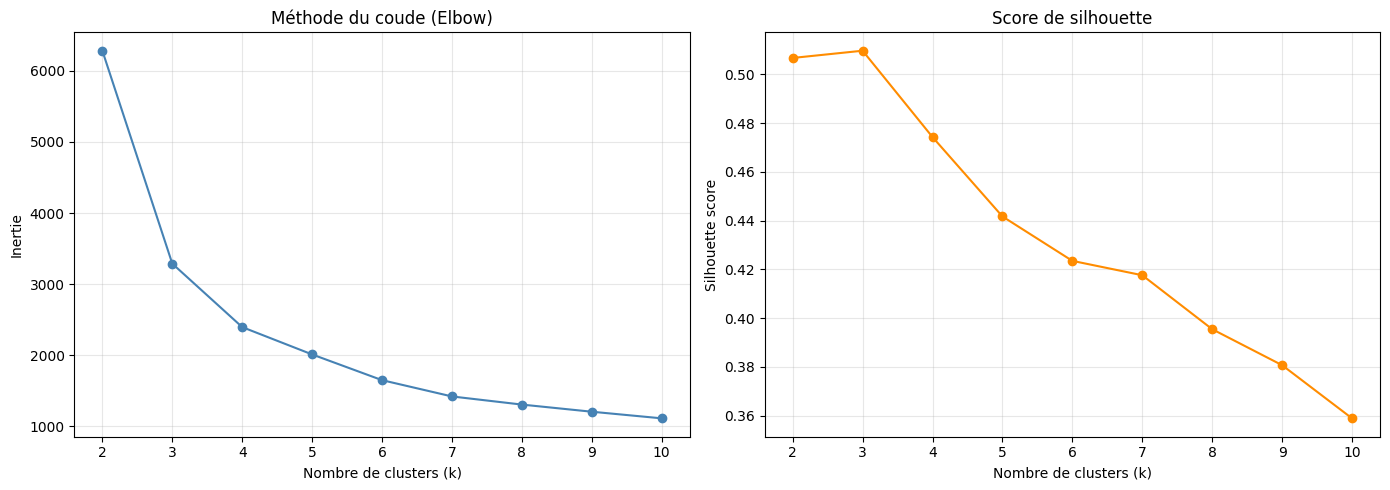

k=2 | inertie=6285.5 | silhouette=0.507
k=3 | inertie=3286.9 | silhouette=0.510
k=4 | inertie=2393.1 | silhouette=0.474
k=5 | inertie=2008.3 | silhouette=0.442
k=6 | inertie=1646.0 | silhouette=0.423
k=7 | inertie=1416.6 | silhouette=0.418
k=8 | inertie=1302.1 | silhouette=0.395
k=9 | inertie=1201.5 | silhouette=0.381
k=10 | inertie=1108.3 | silhouette=0.359


In [21]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o', color='steelblue')
axes[0].set_title("Méthode du coude (Elbow)")
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie')
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, silhouette_scores, marker='o', color='darkorange')
axes[1].set_title('Score de silhouette')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

for k, i, s in zip(k_range, inertias, silhouette_scores):
    print(f'k={k} | inertie={i:.1f} | silhouette={s:.3f}')

**Choix de k = 4** : le coude s'aplatit nettement à partir de k=4, et le score de
silhouette y reste élevé (>0.45) tout en offrant une segmentation plus riche et plus
exploitable commercialement que k=2 ou k=3 (qui restent trop génériques pour le marketing).

In [22]:
K_OPTIMAL = 4

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f'Modèle K-Means entraîné avec k={K_OPTIMAL} ')
print()
print('Répartition des clients par cluster :')
print(rfm['Cluster'].value_counts().sort_index())

Modèle K-Means entraîné avec k=4 

Répartition des clients par cluster :
Cluster
0     853
1    1009
2    1907
3     569
Name: count, dtype: int64


### 4.4 — Visualisation des clusters

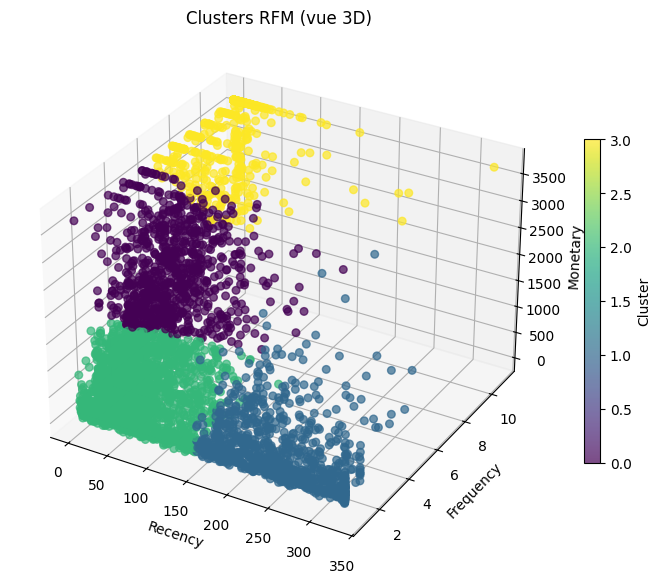

In [23]:
# Visualisation 3D directe (R, F, M)
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'],
                      c=rfm['Cluster'], cmap='viridis', s=30, alpha=0.7)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('Clusters RFM (vue 3D)')
plt.colorbar(scatter, label='Cluster', shrink=0.6)
plt.show()

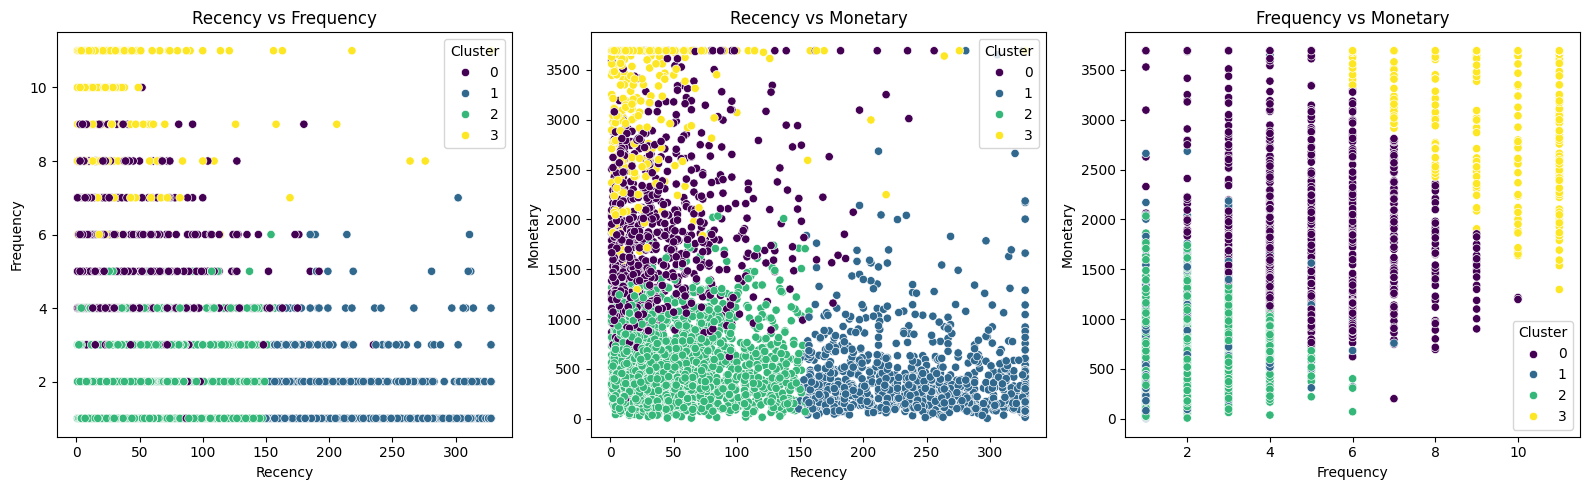

In [24]:
# Visualisation 2D par paires de variables (plus lisible pour le rapport)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [('Recency', 'Frequency'), ('Recency', 'Monetary'), ('Frequency', 'Monetary')]
for i, (x, y) in enumerate(pairs):
    sns.scatterplot(data=rfm, x=x, y=y, hue='Cluster', palette='viridis', ax=axes[i])
    axes[i].set_title(f'{x} vs {y}')
plt.tight_layout()
plt.show()

---
## PARTIE 5 — INTERPRÉTATION MÉTIER

On calcule le **profil moyen** (R, F, M) de chaque cluster pour comprendre
ce qu'il représente concrètement, puis on lui attribue un **label métier**.

In [25]:
profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
profile['NbClients'] = rfm['Cluster'].value_counts().sort_index()
profile['% Clients'] = (profile['NbClients'] / profile['NbClients'].sum() * 100).round(1)
profile

,Recency,Frequency,Monetary,NbClients,% Clients
Cluster,,,,,
0,39.8,5.0,1951.5,853,19.7
1,248.3,1.4,410.9,1009,23.3
2,52.8,2.0,539.7,1907,44.0
3,20.3,9.9,3373.3,569,13.1


C:\Users\Admin\AppData\Local\Temp\ipykernel_8868\4071667070.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profile.index, y=profile[col], palette='viridis', ax=axes[i])
C:\Users\Admin\AppData\Local\Temp\ipykernel_8868\4071667070.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profile.index, y=profile[col], palette='viridis', ax=axes[i])
C:\Users\Admin\AppData\Local\Temp\ipykernel_8868\4071667070.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profile.index, y=profile[col], palette='viridis', ax=axes[i])


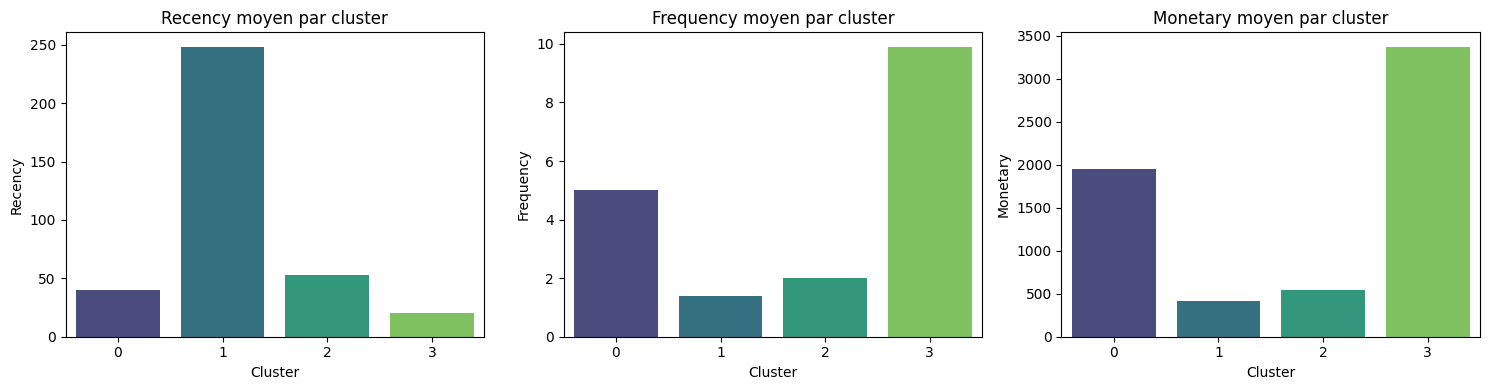

In [26]:
# Visualisation comparative des profils
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    sns.barplot(x=profile.index, y=profile[col], palette='viridis', ax=axes[i])
    axes[i].set_title(f'{col} moyen par cluster')
    axes[i].set_xlabel('Cluster')
plt.tight_layout()
plt.show()

### Labels métier attribués

| Cluster | Recency | Frequency | Monetary | % clients | Label métier |
|---|---|---|---|---|---|
| 3 | faible (~20j) | élevée (~10) | élevé (~3370€) | ~13% | 🏆 **Clients premium** — achètent souvent, récemment, dépensent beaucoup |
| 0 | faible (~40j) | moyenne (~5) | bon (~1950€) | ~20% | ⭐ **Clients fidèles** — réguliers, bonne valeur, encore actifs |
| 2 | moyenne (~53j) | faible (~2) | faible (~540€) | ~44% | 🙂 **Clients occasionnels** — la majorité, achats peu fréquents et modestes |
| 1 | élevée (~248j) | faible (~1.4) | faible (~410€) | ~23% | ⚠️ **Clients à risque / perdus** — pas revus depuis longtemps |

**Recommandations marketing :**
- **Premium** → programme VIP, accès anticipé aux nouveautés, pas de relance agressive nécessaire
- **Fidèles** → maintenir l'engagement (cross-sell, programme de fidélité)
- **Occasionnels** → campagnes d'activation, offres pour augmenter la fréquence d'achat
- **À risque/perdus** → campagne de réactivation (coupon, email de relance), sinon risque de churn total

In [27]:
# On ajoute le label métier directement dans le tableau RFM (utile pour Streamlit)
label_map = {3: 'Premium', 0: 'Fidèle', 2: 'Occasionnel', 1: 'À risque'}
rfm['Segment'] = rfm['Cluster'].map(label_map)

rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']].head(10)

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326.0,1.0,3691.77,1,À risque
1,12347.0,2.0,7.0,3691.77,3,Premium
2,12348.0,75.0,4.0,1797.24,0,Fidèle
3,12349.0,19.0,1.0,1757.55,2,Occasionnel
4,12350.0,310.0,1.0,334.40,1,À risque
5,12352.0,36.0,8.0,2506.04,3,Premium
6,12353.0,204.0,1.0,89.00,1,À risque
7,12354.0,232.0,1.0,1079.40,1,À risque
8,12355.0,214.0,1.0,459.40,1,À risque
9,12356.0,23.0,3.0,2811.43,0,Fidèle


In [28]:
# Sauvegarde des artefacts nécessaires pour l'application Streamlit (Partie 6)
import pickle

pickle.dump(kmeans, open('kmeans_model.pkl', 'wb'))
pickle.dump(scaler, open('rfm_scaler.pkl', 'wb'))
rfm.to_csv('rfm_clustered.csv', index=False)

print('Modèle, scaler et données RFM clusterisées sauvegardés ')
print('Fichiers : kmeans_model.pkl, rfm_scaler.pkl, rfm_clustered.csv')

Modèle, scaler et données RFM clusterisées sauvegardés 
Fichiers : kmeans_model.pkl, rfm_scaler.pkl, rfm_clustered.csv



### PARTIE 7 — AMÉLIORATION

On propose ici des pistes pour aller plus loin que le K-Means de base : tester
d'autres algorithmes de clustering, et discuter d'améliorations UI/analyse.

### 7.1 — DBSCAN (clustering basé sur la densité)
Contrairement à K-Means, DBSCAN ne demande pas de fixer k à l'avance et peut
détecter automatiquement les **outliers** (points "bruit"). On teste plusieurs
valeurs de `eps` pour voir si DBSCAN trouve une structure intéressante sur le RFM.

In [29]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

resultats_dbscan = []
for eps in [0.3, 0.5, 0.7, 1.0, 1.3]:
    db = DBSCAN(eps=eps, min_samples=10).fit(rfm_scaled)
    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_bruit = (db.labels_ == -1).sum()
    sil = silhouette_score(rfm_scaled, db.labels_) if n_clusters > 1 else np.nan
    resultats_dbscan.append({'eps': eps, 'n_clusters': n_clusters, 'n_bruit': n_bruit, 'silhouette': sil})

pd.DataFrame(resultats_dbscan)

,eps,n_clusters,n_bruit,silhouette
0,0.3,17,283,-0.009377
1,0.5,1,35,NaN
2,0.7,1,17,NaN
3,1.0,1,4,NaN
4,1.3,1,1,NaN


**Constat :** sur ce jeu de données RFM, DBSCAN ne trouve **pas de structure
satisfaisante** — soit trop de petits clusters de bruit (`eps` faible), soit
un seul cluster géant qui avale tout (`eps` plus grand) avec un score de silhouette
soit négatif soit non calculable. **Explication métier** : les clients RFM forment
un **continuum** (du client occasionnel au client premium, sans "vide" net entre
les groupes), alors que DBSCAN est conçu pour détecter des **îlots de densité
bien séparés par des zones vides**. K-Means, qui découpe l'espace en zones par
proximité au centre, est donc plus adapté ici.

### 7.2 — Clustering Hiérarchique (Agglomerative Clustering)

In [30]:
agglo = AgglomerativeClustering(n_clusters=K_OPTIMAL)
labels_agglo = agglo.fit_predict(rfm_scaled)

sil_agglo = silhouette_score(rfm_scaled, labels_agglo)
sil_kmeans = silhouette_score(rfm_scaled, rfm['Cluster'])

print(f'Silhouette K-Means (k={K_OPTIMAL})      : {sil_kmeans:.3f}')
print(f'Silhouette Agglomerative (k={K_OPTIMAL}) : {sil_agglo:.3f}')

Silhouette K-Means (k=4)      : 0.474
Silhouette Agglomerative (k=4) : 0.440


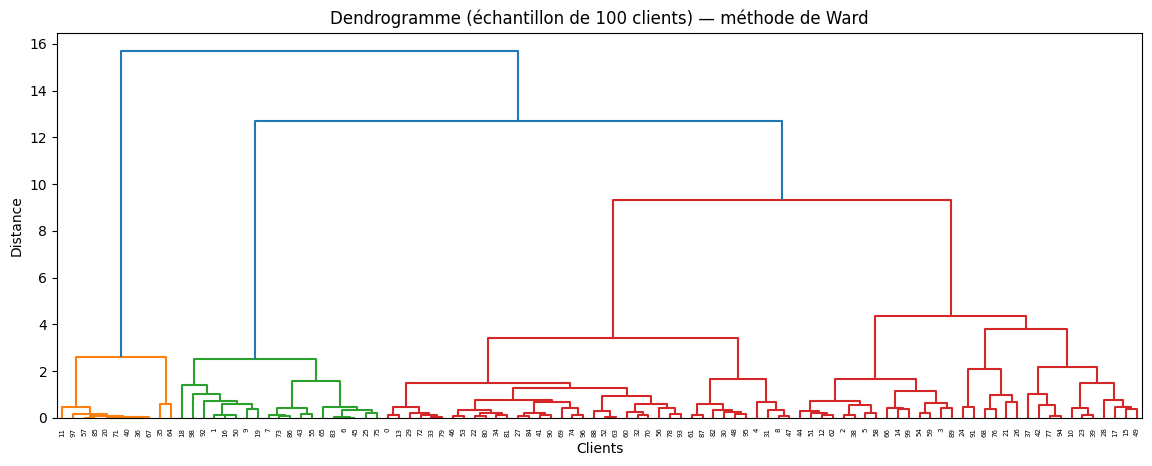

In [31]:
# Dendrogramme (sur un échantillon pour la lisibilité — 4338 clients sont illisibles d'un coup)
echantillon = rfm_scaled[np.random.RandomState(42).choice(len(rfm_scaled), 100, replace=False)]
Z = linkage(echantillon, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z)
plt.title('Dendrogramme (échantillon de 100 clients) — méthode de Ward')
plt.xlabel('Clients')
plt.ylabel('Distance')
plt.show()

**Constat :** le clustering hiérarchique donne une silhouette proche de celle de
K-Means (légèrement inférieure ici), ce qui **confirme la robustesse de la
segmentation en 4 groupes** trouvée précédemment — deux méthodes différentes
convergent vers une structure similaire. L'avantage du hiérarchique est le
**dendrogramme**, utile pour justifier visuellement le choix du nombre de clusters
auprès d'un public non technique (le marketing, par exemple).

### 7.3 — Autres pistes d'amélioration proposées (hors notebook)

- **Meilleure UI Streamlit** :
  - Ajouter un historique des prédictions (table des clients déjà testés dans la session)
  - Permettre l'upload d'un fichier CSV de plusieurs clients pour une segmentation en masse
  - Ajouter des filtres (par pays, par période) sur la vue d'ensemble
  - Thème sombre / responsive mobile

- **Analyse plus poussée** :
  - Croiser les segments RFM avec la variable `Country` (les segments premium sont-ils
    concentrés dans certains pays ?)
  - Étudier les produits (`Description`/`StockCode`) les plus achetés par segment
    (utile pour des recommandations ciblées)
  - Suivre l'**évolution temporelle** des segments (un client "Fidèle" glisse-t-il
    vers "À risque" au fil des mois ? → RFM glissant, recalculé chaque mois)
  - Tester un **4ème indicateur** (ex: diversité des produits achetés) pour enrichir
    le RFM en RFMD
